In [32]:
import numpy as np


size = 10240
true_mean = 3
true_std = 0.5
samples = np.random.normal(loc=true_mean, scale=true_std, size=(size))

### First version: Update per sample

In [33]:
running_m = np.zeros(shape=(size, 1))
running_v = np.zeros(shape=(size, 1))

running_m[0] = samples[0]

for i in range(1, size):
    running_m[i] = running_m[i - 1] + (samples[i] - running_m[i - 1]) / (i + 1)
    running_v[i] = running_v[i - 1] + ((samples[i] - running_m[i - 1]) * (samples[i] - running_m[i]) - running_v[i - 1]) / (i + 1)

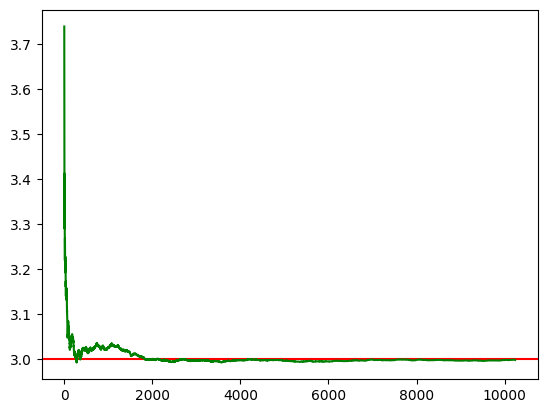

In [34]:
import matplotlib.pyplot as plt

x = np.arange(stop=size, step=1)
plt.axhline(y=true_mean, color='r', linestyle='-')
plt.plot(x, running_m, color='g')

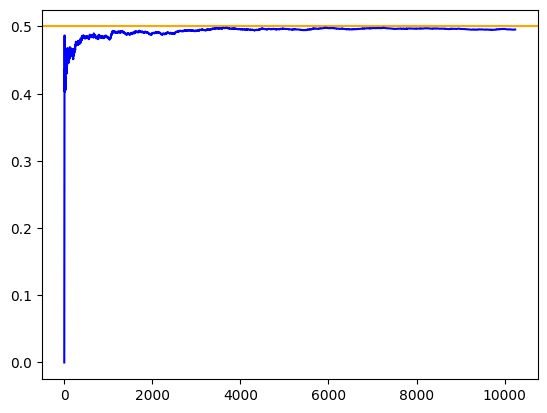

In [35]:
plt.axhline(y=true_std, color='orange', linestyle='-')
plt.plot(x, np.sqrt(running_v), color='b')

### Second approach: Update per batch

In [42]:
batch_size = 16
running_m = np.zeros(shape=(int(size / batch_size), 1))
running_v = np.zeros(shape=(int(size / batch_size), 1))

running_m[0] = np.mean(samples[0:batch_size])
running_v[0] = np.mean(np.square(samples[0:batch_size] - running_m[0])) 

for i in range(1, int(size / batch_size)):
    curr_m = np.mean(samples[i*batch_size:(i+1)*batch_size])
    running_m[i] = running_m[i - 1] + (curr_m - running_m[i - 1]) / (i + 1)
    running_v[i] = running_v[i - 1] + ((curr_m - running_m[i - 1]) * (curr_m - running_m[i]) - running_v[i - 1]) / (i + 1)

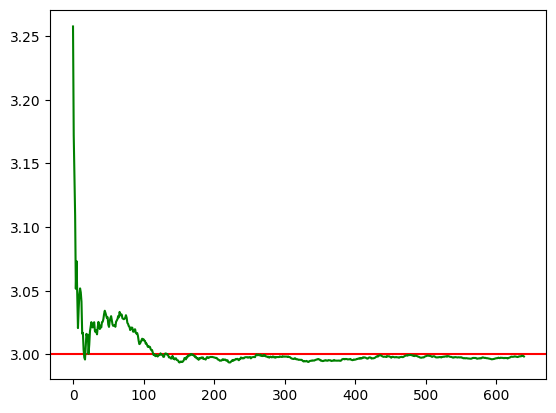

In [43]:
import matplotlib.pyplot as plt

x = np.arange(stop=int(size / batch_size), step=1)
plt.axhline(y=true_mean, color='r', linestyle='-')
plt.plot(x, running_m, color='g')

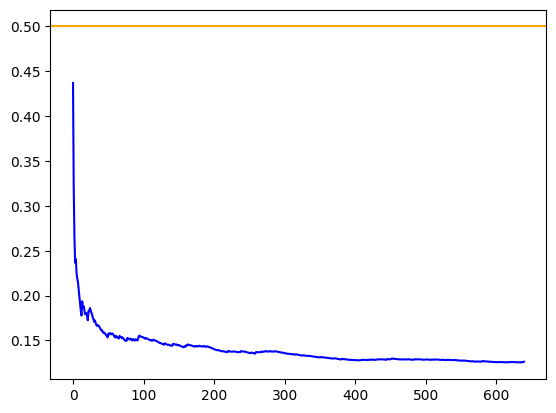

In [44]:
plt.axhline(y=true_std, color='orange', linestyle='-')
plt.plot(x, np.sqrt(running_v), color='b')